**Nama: Richie Darrian Prayogo**  
**NIM: 2802808133**

Link Video Penjelasan: https://www.youtube.com/watch?v=y9B_fn510EY

# 1. Exploratory Data Analysis & Modeling 

## Pemuatan Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

from sklearn.utils.class_weight import compute_sample_weight

import optuna

import warnings

pd.set_option("display.max_columns", None)

In [2]:
feats = pd.read_csv('A.csv')
targets = pd.read_csv('A_targets.csv')

In [3]:
feats.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [4]:
targets.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


## Penggabungan Fitur dan Target

Demi kepentingan analisis, fitur dan target akan digabungkan sementara dan akan dipisahkan nanti ketika sudah siap dikirimkan kepada model untuk belajar.

In [5]:
df = pd.merge(feats, targets, on='Student_ID', how='inner')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [6]:
print('Jumlah kolom:', df.shape[1])
print('Jumlah baris:', df.shape[0])

Jumlah kolom: 25
Jumlah baris: 5000


# EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

Ada beberapa insight yang bisa diperoleh dari pemanggilan .info() tersebut.
- **Missing values signifikan pada `extracurricular_involvement`**. Dari 5000 baris, hanya 3994 yang terisi (berarti ada 1006 nilai hilang, sekitar 20% dan tergolong besar) sehingga perlu ditambahkan tahap imputasi di pipeline model agar data tetap bisa diproses saat training maupun inference. Bahkan, setiap kolom lebih baik ditambahkan tahap imputasi saja buat jaga-jaga di bagian pipelining karena bisa jadi muncul missing values pada batch data terbaru.
- Namun, selain itu **data sudah rapi dan tipe data sesuai konteks**. Tidak ada kolom lain yang memiliki missing values, dan tipe datanya masuk akal:
    - kolom desimal seperti `sleep_hours`, `tenth_percentage`, `twelfth_percentage` bertipe `float`
    - kolom hitungan seperti `certifications_count`, `hackathons_participated`, `internships_completed` bertipe numerik diskrit (`int`)
    - kolom kategori seperti `placement_status`, `extracurricular_involvement`, dan `family_income_level` bertipe `object`.

In [8]:
df.describe(include='object')

,gender,branch,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status
count,5000,5000,5000,5000,5000,5000,3994,5000
unique,2,5,2,3,3,2,3,2
top,Male,CSE,No,Medium,Tier 2,Yes,Medium,Placed
freq,2999,1522,4007,2466,2023,4461,1501,4303


Berdasarkan ringkasan kolom kategorikal, setiap fitur kategorikal memiliki jumlah kategori yang relatif rendah. Hal ini menunjukkan **tidak ada masalah kardinalitas tinggi** di dataset ini. Dengan kardinalitas yang rendah, model cenderung lebih stabil karena tidak perlu mengestimasi terlalu banyak parameter dibandingkan jumlah data yang tersedia saat dilakukan encoding. Satu masalah yang tampak di sini sudah dijelaskan pada langkah sebelumnya, yaitu terdapat cukup banyak jumlah missing values pada kolom `extracurricular_involvement`.

In [9]:
print(df.describe(exclude='object'))

        Student_ID         cgpa  tenth_percentage  twelfth_percentage  \
count  5000.000000  5000.000000       5000.000000         5000.000000   
mean   2500.500000     8.283798         74.537400           74.543060   
std    1443.520003     1.008391         10.266752           10.244481   
min       1.000000     5.000000         50.000000           50.000000   
25%    1250.750000     7.610000         67.400000           67.600000   
50%    2500.500000     8.320000         74.700000           74.800000   
75%    3750.250000     9.020000         82.000000           81.700000   
max    5000.000000    10.000000        100.000000          100.000000   

          backlogs  study_hours_per_day  attendance_percentage  \
count  5000.000000          5000.000000            5000.000000   
mean      0.343600             4.041120              72.041560   
std       0.612547             1.967754               7.720029   
min       0.000000             0.000000              44.700000   
25%       0.

**Setiap angka minimum dan maksimum dari masing-masing kolom valid dan semua masuk akal** berdasarkan maknanya sehingga tidak ada penanganan lanjutan yang perlu dilakukan di sini.

### Categorical Checks

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for c in cat_cols:
    print(f"Kategori unik untuk {c} beserta jumlahnya:")
    print(df[c].value_counts(dropna=False), end='\n\n')

Kategori unik untuk gender beserta jumlahnya:
gender
Male      2999
Female    2001
Name: count, dtype: int64

Kategori unik untuk branch beserta jumlahnya:
branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64

Kategori unik untuk part_time_job beserta jumlahnya:
part_time_job
No     4007
Yes     993
Name: count, dtype: int64

Kategori unik untuk family_income_level beserta jumlahnya:
family_income_level
Medium    2466
Low       1503
High      1031
Name: count, dtype: int64

Kategori unik untuk city_tier beserta jumlahnya:
city_tier
Tier 2    2023
Tier 3    1547
Tier 1    1430
Name: count, dtype: int64

Kategori unik untuk internet_access beserta jumlahnya:
internet_access
Yes    4461
No      539
Name: count, dtype: int64

Kategori unik untuk extracurricular_involvement beserta jumlahnya:
extracurricular_involvement
Medium    1501
Low       1485
High      1008
NaN       1006
Name: count, dtype: int64

Kategori unik untuk placement_status beserta j

Dari ringkasan di atas, bisa diperoleh beberapa insight terkait encoding kolom-kolom kategorikal:
- **Kolom yang cocok untuk One-Hot Encoding** berupa `gender`, `branch`, `part_time_job`, `internet_access`, dan `placement_status` karena termasuk kategori nominal. Artinya, tidak memiliki urutan atau tingkatan yang bermakna. Karena tidak ada hubungan urutan, maka One-Hot Encoding digunakan agar model tidak menganggap ada hubungan numerik antarkategori. Setiap kategori diubah menjadi kolom biner (0/1) yang berdiri sendiri. Contohnya:
    - `gender` -> tidak ada urutan antara laki-laki dan perempuan
    - `branch` -> jurusan tidak bisa dibandingkan lebih tinggi/rendah
    - `part_time_job` -> hanya status ya/tidak
    - `internet_access` -> ada atau tidak
- **Kolom yang cocok untuk Ordinal Encoding** berupa `family_income_level`, `city_tier`, dan `extracurricular_involvement` karena memiliki urutan atau hierarki yang jelas sehingga lebih tepat menggunakan Ordinal Encoding. Di sini, kategori memang memiliki makna “lebih tinggi” atau “lebih rendah” sehingga aman direpresentasikan dengan angka (misalnya 0, 1, 2). Model bisa memanfaatkan informasi urutan ini untuk belajar pola yang lebih baik.
- Karena semua merupakan kolom kategorikal, maka akan dilakukan **imputasi modus** secara otomatis untuk jaga-jaga apabila ada data hilang yang masuk ke pipeline nantinya.

### Numerical Checks

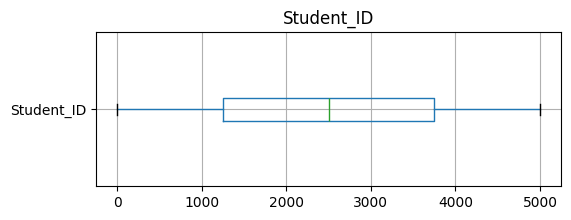

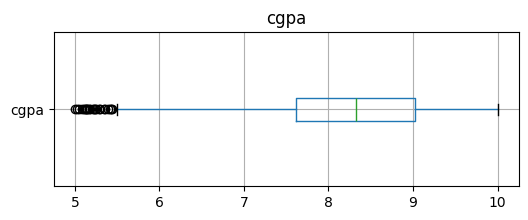

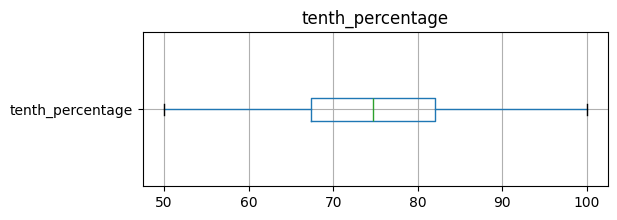

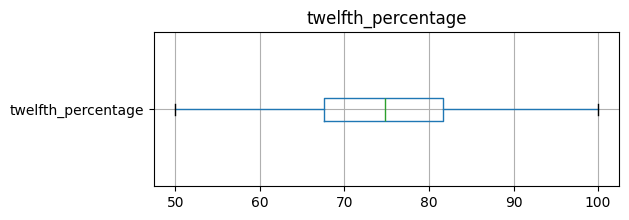

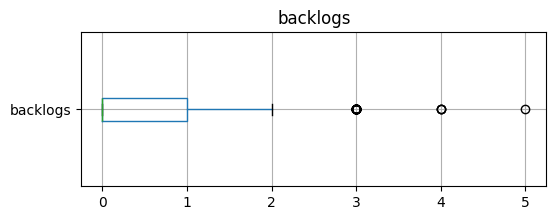

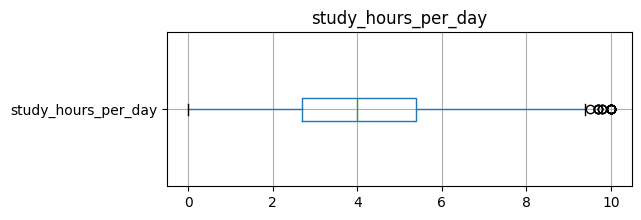

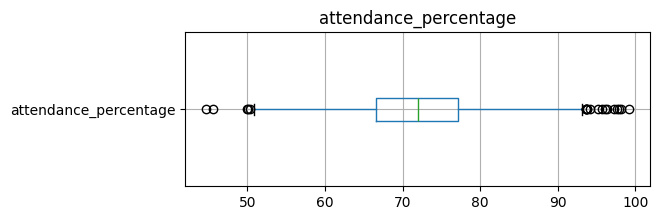

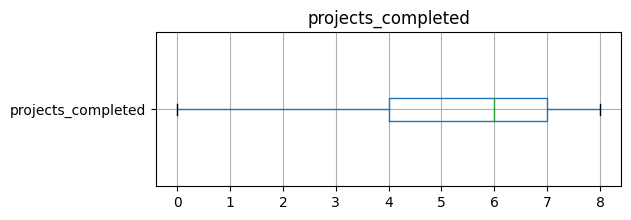

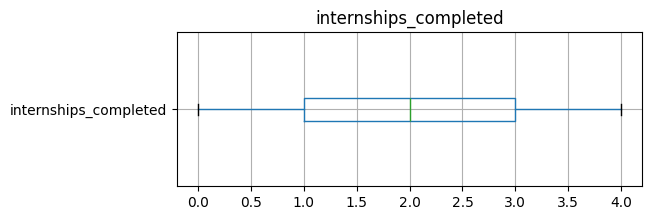

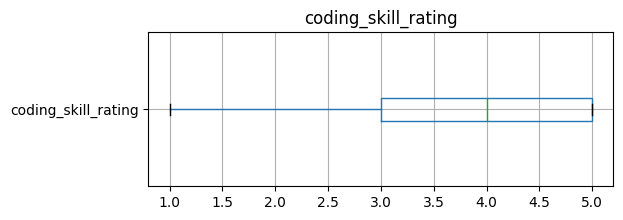

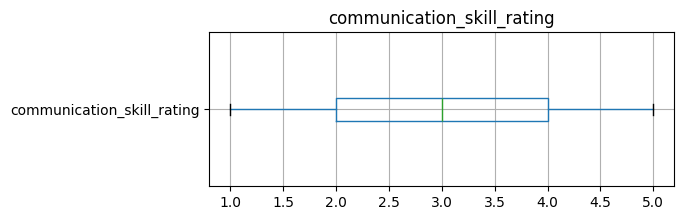

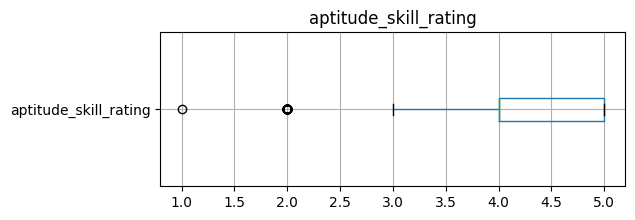

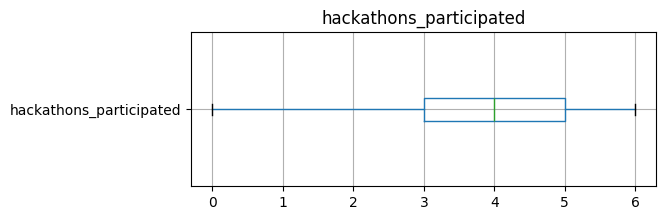

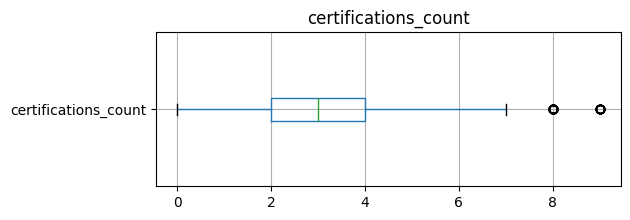

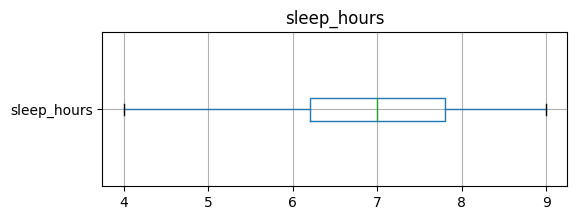

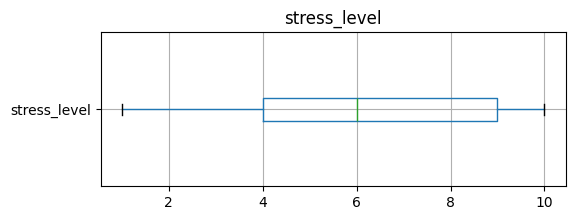

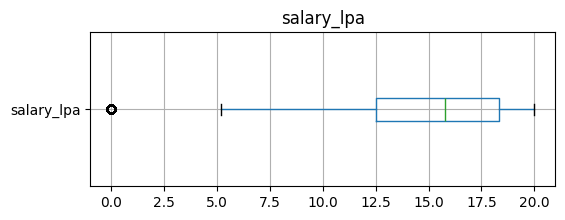

Kolom: Student_ID
  Persentase Outlier: 0.00%
  Skewness: 0.000
----------------------------------------
Kolom: cgpa
  Persentase Outlier: 0.46%
  Skewness: -0.288
----------------------------------------
Kolom: tenth_percentage
  Persentase Outlier: 0.00%
  Skewness: -0.135
----------------------------------------
Kolom: twelfth_percentage
  Persentase Outlier: 0.00%
  Skewness: -0.091
----------------------------------------
Kolom: backlogs
  Persentase Outlier: 0.84%
  Skewness: 1.903
----------------------------------------
Kolom: study_hours_per_day
  Persentase Outlier: 0.40%
  Skewness: 0.107
----------------------------------------
Kolom: attendance_percentage
  Persentase Outlier: 0.40%
  Skewness: 0.036
----------------------------------------
Kolom: projects_completed
  Persentase Outlier: 0.00%
  Skewness: -0.533
----------------------------------------
Kolom: internships_completed
  Persentase Outlier: 0.00%
  Skewness: -0.088
----------------------------------------
Kolom

In [11]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

for col in num_cols:
    vals = df[col].dropna()

    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = vals[(vals < LB) | (vals > UB)]
    outlier_pct = (len(outliers) / len(vals)) * 100

    skewness = vals.skew()

    print(f"Kolom: {col}")
    print(f"  Persentase Outlier: {outlier_pct:.2f}%")
    print(f"  Skewness: {skewness:.3f}")
    print("-" * 40)

Dengan menggunakan rule of thumb yang telah saya definisikan, yaitu outlier > 5% atau skewness < -0.5 / > 0.5 menandakan distribusi yang tidak normal:
 - Sebagian besar fitur numerik seperti `cgpa`, `tenth_percentage`, `twelfth_percentage`, `study_hours_per_day`, `attendance_percentage`, `internships_completed`, `communication_skill_rating`, `aptitude_skill_rating`, `hackathons_participated`, `sleep_hours`, dan `stress_level` tidak menunjukkan masalah outlier yang signifikan maupun skewness ekstrem sehingga  **aman digunakan Standard Scaler dengan mean imputation** karena distribusinya relatif mendekati normal sekaligus memberi representasi nilai tengah dari distribusi nilai yang lebih akurat.
 - Namun, beberapa fitur seperti `backlogs` (skewness tinggi), `certifications_count` (skewness > 0.5), `projects_completed` (skewness < -0.5) dan `coding_skill_rating` (skewness < -0.5) masuk kategori bermasalah, baik karena outlier besar atau distribusi miring, sehingga **lebih baik menggunakan Robust Scaler dengan median imputation** agar tidak terlalu terpengaruh oleh nilai ekstrem dan distribusi yang tidak simetris.
 - Khusus untuk `salary_lpa`, meskipun memiliki outlier tinggi (~14%) dan skewness -1.336, fitur ini merupakan salah satu kolom target sehingga tidak wajib dilakukan scaling seperti fitur input. Sebagai gantinya, akan digunakan **model yang robust terhadap outlier** sehingga model tidak terlalu dipengaruhi oleh nilai ekstrem. Dengan menggunakan model seperti tree-based (misalnya Random Forest atau Gradient Boosting) atau, distribusi target dapat tetap dipertahankan tanpa perlu transformasi tambahan, dan tetap menghasilkan performa yang stabil.

### Duplicates Check

In [12]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 0


Tidak ada row duplikat sehingga tugas kolom identifier yang menunjukkan keunikan masing-masing row sudah selesai sampai sini saja sehingga bisa langsung di-drop saja.

In [13]:
df = df.drop(columns=["Student_ID"])

In [14]:
df.head(5)

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


### Data Imbalance Check

In [15]:
df["placement_status"].value_counts(normalize=True)

placement_status
Placed        0.8606
Not Placed    0.1394
Name: proportion, dtype: float64

Karena proporsi antarkategori target jomplang, maka kasus ini disebut dengan **data imbalance**. Model ML akan cenderung untuk hanya generalisasi kepada kategori 'Placed' dibandingkan kategori 'Not Placed' sehingga model kemungkinan besar memiliki performa yang relatif buruk ketika diminta untuk memprediksi 'Not Placed'. Oleh karena itu, saya akan coba mengatasinya menggunakan **class weighting** nantinya.

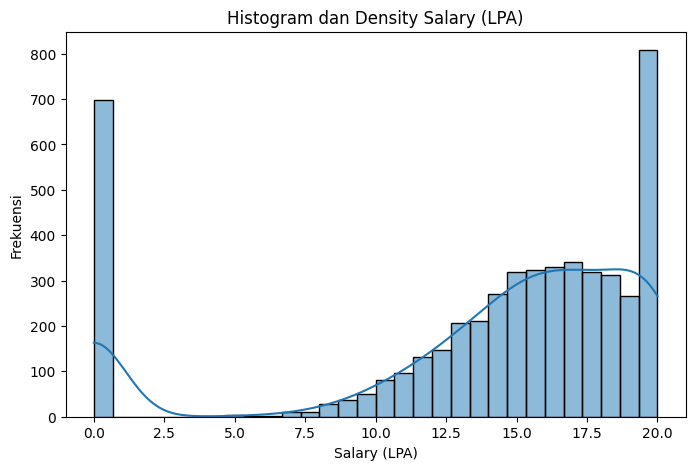

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["salary_lpa"], kde=True)
plt.title("Histogram dan Density Salary (LPA)")
plt.xlabel("Salary (LPA)")
plt.ylabel("Frekuensi")
plt.show()

In [17]:
not_placed_count = (df["placement_status"] == "Not Placed").sum()
salary_zero_count = (df["salary_lpa"] == 0).sum()

print("Jumlah placement_status = 'Not Placed':", not_placed_count)
print("Jumlah salary_lpa = 0:", salary_zero_count)

Jumlah placement_status = 'Not Placed': 697
Jumlah salary_lpa = 0: 697


Dari grafik histogram tersebut, saya melihat bahwa tidak ada atau hampir tidak ada data yang tersebar di antara 1 sampai 6, tetapi ada banyak sekali nilai salary_lpa yang terkonsentrasi pada nilai 0. Ditambah lagi, ternyata yang tidak memiliki salary lpa juga selalu memiliki placement_status Not Placed, yang menandakan bahwa jika seseorang Not Placed, maka dia tidak memiliki salary_lpa sama sekali. Ditambah lagi, tidak ada nilai salary yang lebih besar daripada 20 yang kemungkinan besar akibat semua nilai yang lebih dari itu diclipping menjadi 20 saja. Hal ini memberikan ide kepada pipeline ML yang nantinya akan dibangun:
1. Model klasifikasi akan pertama-tama memprediksi kolom target Placed atau Not Placed.
2. Setelah itu, apabila ternyata diprediksi Not Placed, maka nilai salary akan otomatis dijadikan 0 karena tidak masuk akal seseorang yang tidak ditempatkan malah dapat salary.
3. Model regresi akan dibangun untuk hanya memprediksi nilai salary pada mahasiswa yang Placed. Hal ini dikarenakan semua nilai 0 itu sudah direpresentasikan oleh Not Placed yang sudah diprediksi oleh model klasifikasi tadi. Sementara itu, semua nilai yang lebih dari 20 akan langsung di-clipping menjadi 20 untuk menunjukkan karakteristik kolom target yang tidak memiliki nilai lebih dari 20.

Artinya, untuk analisis korelasi nantinya dan pembangunan model, **semua yang bernilai nol akan langsung dihilangkan dari train dan test set model regresi** supaya dia hanya fokus ke nilai-nilai yang memiliki variasi.

In [18]:
df_reg = df[df["placement_status"] == "Placed"].copy()
df_reg = df_reg.drop(columns=["placement_status"])

df_class = df.copy()
df_class = df_class.drop(columns=["salary_lpa"])

In [19]:
df_reg.head()

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,14.52
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,15.91


In [20]:
df_class.head()

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,4,2,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,3,4,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,5,1,4,6,3,6.1,2,No,Low,Tier 2,Yes,High,Placed
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,3,1,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,2,5,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed


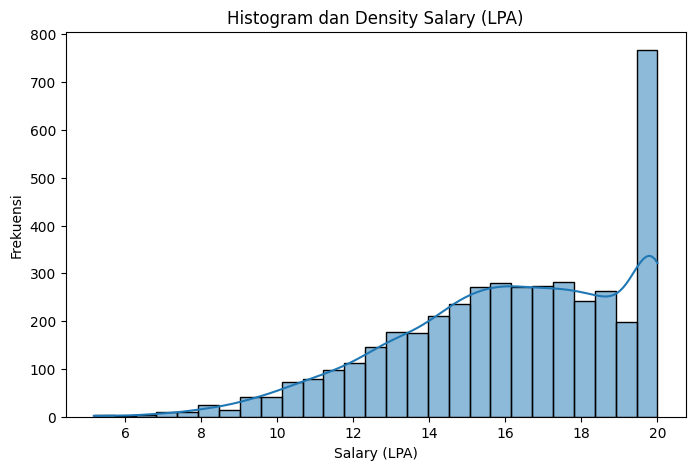

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df_reg["salary_lpa"], kde=True)
plt.title("Histogram dan Density Salary (LPA)")
plt.xlabel("Salary (LPA)")
plt.ylabel("Frekuensi")
plt.show()

### Correlation and Association Check

#### Numerikal x Numerikal (Korelasi Pearson)

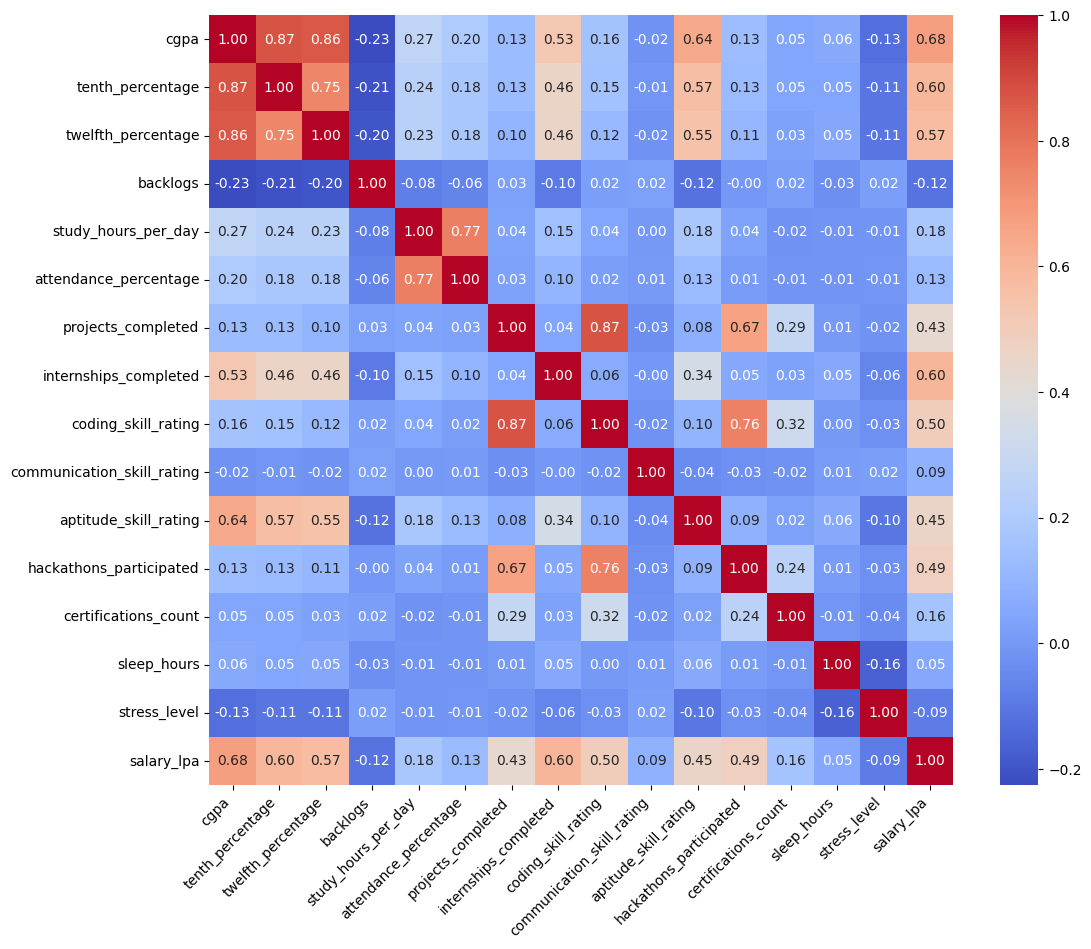

In [22]:
plt.figure(figsize=(12,10))
sns.heatmap(df_reg.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Insight yang diperoleh dari analisis korelasi menggunakan tabel interpretasi Pearson Correlation dari ResearchGate (https://www.researchgate.net/figure/Interpretation-of-Correlation-Coefficient_tbl4_323336704):
- Terlihat adanya **multikolinearitas** yang sangat tinggi antara `cgpa`, `tenth_percentage`, dan `twelfth_percentage` (korelasi 0.77–0.88) yang berarti ketiga fitur ini membawa informasi yang sangat mirip. Meskipun ini bisa menjadi masalah pada model linear, dampaknya dapat diminimalkan dengan menggunakan model berbasis tree seperti Random Forest, XGBoost, LightGBM, atau CatBoost yang lebih robust terhadap multikolinearitas.
- Selain itu, **sebagian besar fitur menunjukkan korelasi yang cukup kuat terhadap target** `salary_lpa` (misalnya `cgpa` 0.68, `internships` 0.60, `projects` 0.43, `coding_skill` 0.50) yang menandakan fitur-fitur tersebut relevan untuk prediksi gaji.
- Terdapat juga **korelasi negatif yang cukup jelas** seperti backlogs (-0.12) yang mengindikasikan bahwa semakin banyak tunggakan akademik, semakin rendah estimasi gaji. Hal ini mungkin dikarenakan `backlogs` mencerminkan adanya kesulitan dalam menyelesaikan studi tepat waktu sehingga dapat menurunkan daya saing kandidat di mata recruiter serta mengurangi peluang mendapatkan posisi dengan gaji tinggi.
- Di sisi lain, **`sleep_hours` (0.05) memiliki korelasi yang sangat lemah** (mendekati nol) sehingga dapat dianggap sebagai fitur yang paling tidak signifikan dalam memprediksi target karena tidak memberikan sinyal hubungan yang berarti terhadap variasi gaji. Korelasi yang lemah ini terjadi mungkin karena durasi tidur tidak memiliki hubungan langsung dengan faktor penentu utama gaji seperti keterampilan, pengalaman, dan performa akademik, sehingga variasinya tidak cukup menjelaskan perubahan pada nilai gaji. Meskipun demikian, nilainya masih berada di atas 0.01 sehingga dalam batas tertentu tetap memiliki sedikit sinyal prediktif meskipun kontribusinya sangat kecil.

#### `placement_status` x Kategorikal (Chi-Square Test & Cramer's V)

In [23]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

cat_cols = df_class.select_dtypes(include='object').columns

In [24]:
results = []
target = 'placement_status'

for col in cat_cols:
    if col == target:
        continue
        
    contingency = pd.crosstab(df_class[col], df_class[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    cramers_v = (phi2 / min(k-1, r-1))**0.5

    results.append({
        'Feature': col,
        'Chi2': chi2,
        'p_value': p,
        'Cramers_V': cramers_v
    })

results_df = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)
results_df.T

,1,5,4,2,6,3,0
Feature,branch,internet_access,city_tier,part_time_job,extracurricular_involvement,family_income_level,gender
Chi2,97.694501,13.944453,0.26654,0.161302,0.076766,0.030439,0.002183
p_value,0.0,0.000188,0.875229,0.687961,0.962344,0.984896,0.962737
Cramers_V,0.139782,0.05281,0.007301,0.00568,0.004384,0.002467,0.000661


H0: The two variables are independent (no relationship)  
H1: The two variables are related 

Menggunakan tabel dari ResearchGate (https://www.researchgate.net/figure/Interpretation-of-Cramers-V-values_tbl4_382584046) untuk menginterpretasi hasil uji Chi-Square dan dan nilai Cramer's V:
- **Hampir tidak ada variabel kategorikal yang memiliki asosiasi kuat dengan `placement_status`** karena sebagian besar nilai Cramer's V sangat rendah (mendekati 0), yang menunjukkan hubungan yang lemah atau hampir tidak ada hubungan praktis meskipun beberapa variabel signifikan secara statistik (p-value < 0.05). Variabel yang memiliki asosiasi yang relatif tinggi adalah `branch` (Cramer's V hampir 0.14 yang menunjukkan asosiasi moderat) sehingga pengaruhnya terhadap keberhasilan penempatan kerja tetap terbatas, yang disusul oleh `internet_access` dengan nilai Cramers_V menyentuh batas bawah asosiasi rendah.
- Variabel lain seperti `city_tier`, `part_time_job`, hingga `gender` memiliki nilai Cramer's V yang sangat kecil (<0,05), menandakan bahwa **fitur-fitur tersebut tidak memberikan kontribusi berarti dalam membedakan status penempatan kerja** sehingga kemungkinan besar faktor lain di luar variabel kategorikal ini lebih dominan dalam menentukan outcome.

#### `salary_lpa` x Kategorikal (ANOVA Test)

In [25]:
results_salary = []
target_num = 'salary_lpa'

cat_cols = df_reg.select_dtypes(include='object').columns

for cat_col in cat_cols:
    groups = [
        df_reg.loc[df_reg[cat_col] == cat, target_num].dropna()
        for cat in df_reg[cat_col].dropna().unique()
        if cat != "placement_status"
    ]
    
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        f_stat, p_value = f_oneway(*groups)
        
        all_vals = np.concatenate(groups)
        grand_mean = all_vals.mean()
        
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = ((all_vals - grand_mean) ** 2).sum()
        
        eta_squared = ss_between / ss_total

        results_salary.append({
            "Categorical": cat_col,
            "Target": target_num,
            "p_value": p_value,
            "eta_squared": eta_squared
        })

anova_salary_df = pd.DataFrame(results_salary).sort_values(by="eta_squared", ascending=False)
anova_salary_df.T

,1,5,4,6,3,0,2
Categorical,branch,internet_access,city_tier,extracurricular_involvement,family_income_level,gender,part_time_job
Target,salary_lpa,salary_lpa,salary_lpa,salary_lpa,salary_lpa,salary_lpa,salary_lpa
p_value,0.0,0.0,0.221464,0.31769,0.467783,0.562194,0.928653
eta_squared,0.084651,0.006253,0.000701,0.000671,0.000353,0.000078,0.000002


H0: any observed differences in sample means are due to random variation  
H1: at least one sample means difference exist  

Menggunakan tabel dari ResearchGate (https://www.researchgate.net/figure/Interpretation-of-Eta-Squared-Values_tbl6_368801417) untuk interpretasi uji ANOVA dan eta squared:
- Untuk target `salary_lpa`, ANOVA menunjukkan bahwa `branch` dan `internet_access` memiliki p-value = 0.0 sehingga signifikan terhadap variasi gaji. Kedua variabel memiliki pengaruh yang kecil dengan `branch` (pengaruh kecil, eta squared = 0.08) dan `internet_access` (pengaruh sangat kecil, eta squared = 0.006), tetapi hanya `branch` yang akan digunakan untuk memprediksi nantinya karena `internet access` dikategorikan sebagai negligible (<0.01).
- Sementara itu, **variabel lain** seperti `extracurricular_involvement`, `family_income_level`, `city_tier`, `part_time_job`, dan `gender` memiliki p-value tinggi (>0.05) sehingga **tidak signifikan dengan kontribusi yang nyaris nol**. Ini menunjukkan bahwa tanpa melibatkan target lain, faktor yang memengaruhi gaji dalam model ini relatif terbatas dan efeknya cenderung kecil.

#### `placement_status` X Numerikal (ANOVA Test)

In [26]:
results_num_vs_placement = []
target = 'placement_status'

cat_cols = df_class.select_dtypes(include='object').columns
num_cols = df_class.select_dtypes(include='number').columns

for num_col in num_cols:
    groups = [
        df_class.loc[df_class[target] == cat, num_col].dropna()
        for cat in df_class[target].dropna().unique()
    ]
    
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        f_stat, p_value = f_oneway(*groups)
        
        all_vals = np.concatenate(groups)
        grand_mean = all_vals.mean()
        
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = ((all_vals - grand_mean) ** 2).sum()
        
        eta_squared = ss_between / ss_total

        results_num_vs_placement.append({
            "Numerical": num_col,
            "Target": target,
            "p_value": p_value,
            "eta_squared": eta_squared
        })

placement_num_df = pd.DataFrame(results_num_vs_placement).sort_values(by="eta_squared", ascending=False)
placement_num_df.T

,3,8,6,0,11,1,2,7,10,12,9,4,14,5,13
Numerical,backlogs,coding_skill_rating,projects_completed,cgpa,hackathons_participated,tenth_percentage,twelfth_percentage,internships_completed,aptitude_skill_rating,certifications_count,communication_skill_rating,study_hours_per_day,stress_level,attendance_percentage,sleep_hours
Target,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status,placement_status
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000004,0.001272,0.002695,0.244305
eta_squared,0.172471,0.1178,0.104197,0.099612,0.076092,0.072727,0.072067,0.064612,0.045701,0.01579,0.005581,0.004228,0.002075,0.0018,0.000271


H0: any observed differences in sample means are due to random variation  
H1: at least one sample means difference exist  

Interpretasi ANOVA berdasarkan https://amandashaker-stm1001-topic-7.share.connect.posit.cloud/6-effect-sizes.html:
- Sebagian besar variabel numerik, seperti `salary_lpa`, `backlogs`, `coding_skill_rating`, `projects_completed`, `cgpa`, `hackathons_participated`, `tenth_percentage`, dan `twelfth_percentage`, memiliki p-value sangat kecil hingga mendekati 0 sehingga berpengaruh signifikan terhadap `placement_status`. Namun, perlu dicatat juga bahwa `salary_lpa` tidak  digunakan sebagai fitur karena `salary_lpa` merupakan target lain (berpotensi menyebabkan data leakage).
- Di luar itu, dari sisi kekuatan pengaruh (eta squared), `coding_skill_rating` (0.12), `projects_completed` (0.10), `cgpa` (0.10). `hackathons_participated` (0.08), `tenth_percentage` (0.07), `twelfth_percentage` (0.07), dan `internship_completed` menunjukkan pengaruh sedang, sementara `aptitude_skill_rating` (0.05) dan `certification_count` (0.02) memiliki pengaruh kecil, tetapi tetap signifikan. Namun, enam kolom terakhir (`communication_skill_rating`, `study_hours_per_day`, `stress_level`, `attendance_percentage`, `sleep_hours`, dan `Student_ID`) menunjukkan pengaruh yang sama tidak signifikan.

## Pemilihan Fitur & Split
Berdasarkan hasil korelasi dan uji-uji statistik yang dilakukan, dipilah beberapa fitur yang baik digunakan untuk masing-masing kolom target.

##### **Fitur-Fitur untuk Memprediksi `salary_lpa`**
Fitur Numerik:
- cgpa (0.68) -> memiliki korelasi cukup kuat, menunjukkan bahwa performa akademik merupakan salah satu faktor utama yang berkaitan dengan peningkatan gaji.
- coding_skill_rating (0.50) -> berkorelasi moderat–cukup kuat, mencerminkan pentingnya keterampilan teknis dalam menentukan nilai gaji.
- internships_completed (0.60) -> korelasi cukup kuat, menunjukkan bahwa pengalaman industri berkontribusi besar terhadap gaji.
- twelfth_percentage (0.57) -> memiliki hubungan moderat–cukup kuat, mengindikasikan kontribusi performa akademik lanjutan.
- tenth_percentage (0.60) -> korelasi cukup kuat, merefleksikan bahwa fondasi akademik awal masih berpengaruh signifikan.
- projects_completed (0.43) -> korelasi moderat, menunjukkan pentingnya pengalaman praktis dalam meningkatkan nilai gaji.
- hackathons_participated (0.49) -> hubungan moderat, mencerminkan aktivitas kompetitif yang relevan dengan skill praktis.
- aptitude_skill_rating (0.45) -> korelasi moderat, menunjukkan kontribusi kemampuan kognitif umum.
- certifications_count (0.16) -> korelasi lemah, namun masih memberikan sedikit sinyal terkait kompetensi.
- study_hours_per_day (0.18) -> korelasi lemah, menunjukkan kontribusi kecil terhadap variasi gaji.
- attendance_percentage (0.13) -> hubungan lemah, mencerminkan pengaruh kedisiplinan yang terbatas.
- sleep_hours (0.05) -> korelasi sangat lemah, hampir tidak memberikan kontribusi praktis.
- stress_level (-0.09) -> korelasi negatif sangat lemah, menunjukkan bahwa peningkatan stres sedikit berkaitan dengan penurunan gaji.
- backlogs (-0.12) -> korelasi negatif lemah, mengindikasikan bahwa hambatan akademik berdampak pada penurunan potensi gaji, meskipun tidak terlalu kuat.

Fitur Kategorikal:
- branch -> memiliki pengaruh kecil (0.057), menunjukkan bahwa bidang studi berkontribusi terhadap variasi gaji meskipun terbatas.

#### **Fitur-Fitur untuk Memprediksi `placement_status`**
Fitur Numerik:
- coding_skill_rating (0.12) -> termasuk medium effect, menunjukkan bahwa keterampilan teknis memiliki pengaruh yang cukup kuat dan menjadi faktor utama dalam menentukan keberhasilan penempatan kerja.
- projects_completed (0.10) -> medium effect, mengindikasikan bahwa pengalaman proyek secara signifikan meningkatkan peluang penempatan kerja.
- cgpa (0.10) -> medium effect, menunjukkan bahwa performa akademik merupakan indikator penting dalam kesiapan kerja.
- hackathons_participated (0.08) -> medium effect, mencerminkan bahwa partisipasi dalam kompetisi praktis berkontribusi cukup besar terhadap employability.
- tenth_percentage (0.07) -> medium effect, menunjukkan bahwa fondasi akademik awal masih memiliki peran yang cukup berarti.
- twelfth_percentage (0.07) -> medium effect, menegaskan bahwa performa akademik sebelum perguruan tinggi tetap relevan.
- internships_completed (sekitar rentang 0.06–0.14) -> medium effect, menunjukkan bahwa pengalaman kerja nyata memberikan kontribusi penting terhadap peluang penempatan kerja.
- aptitude_skill_rating (0.05) -> termasuk small effect, yang berarti kemampuan kognitif umum tetap berpengaruh namun dalam skala yang lebih terbatas.
- certifications_count (0.02) -> small effect, menunjukkan bahwa sertifikasi memiliki kontribusi kecil tetapi tetap signifikan dalam meningkatkan peluang penempatan kerja.

Fitur Kategorikal:
- branch -> memiliki asosiasi moderat (0.14), menunjukkan peran bidang studi terhadap peluang penempatan kerja meskipun tidak dominan.
- internet_access -> berada pada batas bawah asosiasi rendah (0.05), menunjukkan pengaruh yang sangat terbatas.

In [27]:
# Feature selection berdasarkan hasil EDA + statistical tests
# Untuk regresi (target: salary_lpa)
salary_num_features = [
    'cgpa', 'coding_skill_rating', 'internships_completed', 'twelfth_percentage',
    'tenth_percentage', 'projects_completed', 'hackathons_participated',
    'aptitude_skill_rating', 'certifications_count', 'study_hours_per_day',
    'attendance_percentage', 'sleep_hours', 'stress_level', 'backlogs'
]
salary_cat_features = ['branch']
salary_features = [c for c in (salary_num_features + salary_cat_features) if c in df_reg.columns]

# Untuk klasifikasi (target: placement_status)
placement_num_features = [
    'coding_skill_rating', 'projects_completed', 'cgpa', 'hackathons_participated',
    'tenth_percentage', 'twelfth_percentage', 'internships_completed',
    'aptitude_skill_rating', 'certifications_count'
]
placement_cat_features = ['branch', 'internet_access']
placement_features = [c for c in (placement_num_features + placement_cat_features) if c in df_class.columns]

print("Seleksi fitur (salary_lpa):", len(salary_features), salary_features)
print("Selected features (placement_status):", len(placement_features), placement_features)

Seleksi fitur (salary_lpa): 15 ['cgpa', 'coding_skill_rating', 'internships_completed', 'twelfth_percentage', 'tenth_percentage', 'projects_completed', 'hackathons_participated', 'aptitude_skill_rating', 'certifications_count', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'stress_level', 'backlogs', 'branch']
Selected features (placement_status): 11 ['coding_skill_rating', 'projects_completed', 'cgpa', 'hackathons_participated', 'tenth_percentage', 'twelfth_percentage', 'internships_completed', 'aptitude_skill_rating', 'certifications_count', 'branch', 'internet_access']


## Split

Train dan test set akan dipilah fiturnya berdasarkan yang sudah ditentukan sebelumnya untuk kasus klasifikasi dan regresi. Kemudian, dilakukan train-test split dengan rasio 80:20. 

In [28]:
# Split klasifikasi
X_class = df_class.drop(columns=["placement_status"])
y_class = df_class["placement_status"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=1, stratify=y_class)

# Split regresi
X_reg = df_reg.drop(columns=["salary_lpa"])
y_reg = df_reg["salary_lpa"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=1)

print("Split Klasifikasi:", Xc_train.shape, Xc_test.shape, yc_train.shape, yc_test.shape)
print("Split Regresi:", Xr_train.shape, Xr_test.shape, yr_train.shape, yr_test.shape)

Split Klasifikasi: (4000, 22) (1000, 22) (4000,) (1000,)
Split Regresi: (3442, 22) (861, 22) (3442,) (861,)


## Encoding Target Variable

Karena ada beberapa model yang memang tidak bisa menerima target variable dalam bentuk string, maka target variable akan diubah terlebih dahulu ke bentuk label angka.

In [29]:
label_map = {'Not Placed': 0, 'Placed': 1}
yc_train_enc = yc_train.map(label_map)
yc_test_enc  = yc_test.map(label_map)

In [30]:
yc_train_enc.value_counts()

placement_status
1    3442
0     558
Name: count, dtype: int64

In [31]:
yc_test_enc.value_counts()

placement_status
1    861
0    139
Name: count, dtype: int64

## Definisi Pipeline

Sekarang, akan dilakukan pendefinisian pipeline yang mencakup hal-hal berikut.
- Median Imputer dan Robust Scaler untuk kolom numerik yang memiliki distribusi yang skewed.
- Mean Imputer dan Standard Scaler untuk kolom numerik yang memiliki distribusi normal.
- Mode Imputer dan One Hot Encoder untuk kolom kategorikal nominal.
- Mode Imputer dan Ordinal Encoder untuk kolom kategorikal ordinal.

Untuk kolom mana yang dilakukan treatment yang mana sudah dijelaskan di EDA sebelumnya.

In [32]:
# Kolom numerik yang cenderung skew/outlier -> median + robust scaler
robust_num_cols = [c for c in ['backlogs', 'certifications_count', 'projects_completed', 'coding_skill_rating'] if c in Xc_train.columns]
# Kolom numerik lainnya -> mean + standard scaler
standard_num_cols = [c for c in Xc_train.select_dtypes(include='number').columns if c not in robust_num_cols]

# Kolom-kolom kategorikal yang memiliki urutan logis -> mode + ordinal encoding
ordinal_candidates = ['family_income_level', 'city_tier', 'extracurricular_involvement']
ordinal_cols = [c for c in ordinal_candidates if c in Xc_train.columns]
ordinal_map = {
    'family_income_level': ['Low', 'Medium', 'High'],
    'city_tier': ['Tier 3', 'Tier 2', 'Tier 1'],
    'extracurricular_involvement': ['Low', 'Medium', 'High']
}
ordinal_categories = [ordinal_map[c] for c in ordinal_cols]
# Kategorikal nominal yang tidak memiliki urutan logis -> mode + one-hot
onehot_cols = [c for c in Xc_train.select_dtypes(include='object').columns if c not in ordinal_cols]

transformers = []

robust_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
transformers.append(('num_robust', robust_pipe, robust_num_cols))

standard_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
transformers.append(('num_standard', standard_pipe, standard_num_cols))

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
transformers.append(('cat_ordinal', ordinal_pipe, ordinal_cols))

onehot_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
transformers.append(('cat_onehot', onehot_pipe, onehot_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop',
    sparse_threshold=0
)

## Train

### Klasifikasi

#### Dengan Sample Weights

In [33]:
models_clf = {
    'RandomForest': RandomForestClassifier(random_state=1, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=1, tree_method='gpu_hist', eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=1, device='gpu'),
    'CatBoost': CatBoostClassifier(random_state=1, verbose=0, task_type='GPU'),
    'GradientBoosting': GradientBoostingClassifier(random_state=1)
}

results_clf = []

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=yc_train_enc
)

for name, model in models_clf.items():
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(Xc_train, yc_train_enc, model__sample_weight=sample_weights)
    
    pred = pipe.predict(Xc_test)
    prob = pipe.predict_proba(Xc_test)[:, 1]

    acc = accuracy_score(yc_test_enc, pred)
    f1 = f1_score(yc_test_enc, pred, pos_label=1)
    roc = roc_auc_score(yc_test_enc, prob)

    results_clf.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

results_clf = pd.DataFrame(results_clf).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("Perbandingan model klasifikasi (semakin besar semakin baik):")
display(results_clf)

c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:44:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [07:44:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [07:44:05] WARNING: C:\actions-runner\_work\xgboos

[LightGBM] [Info] Number of positive: 3442, number of negative: 558
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1259
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 29
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2050, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (0.08 MB) transferred to GPU in 0.006778 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Perbandingan model klasifikasi (semakin besar semakin baik):


,Model,Accuracy,F1 Score,ROC-AUC
0,GradientBoosting,0.827,0.891672,0.910477
1,RandomForest,0.885,0.936359,0.904440
2,LightGBM,0.873,0.925338,0.902130
3,CatBoost,0.861,0.917311,0.898027
4,XGBoost,0.868,0.923345,0.878742


### Tanpa Class Weights

In [34]:
results_clf = []

for name, model in models_clf.items():
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(Xc_train, yc_train_enc)
    
    pred = pipe.predict(Xc_test)
    prob = pipe.predict_proba(Xc_test)[:, 1]

    acc = accuracy_score(yc_test_enc, pred)
    f1 = f1_score(yc_test_enc, pred, pos_label=1)
    roc = roc_auc_score(yc_test_enc, prob)

    results_clf.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

results_clf = pd.DataFrame(results_clf).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("Perbandingan model klasifikasi (semakin besar semakin baik):")
display(results_clf)

c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:45:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [07:45:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


[LightGBM] [Info] Number of positive: 3442, number of negative: 558
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1259
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 29
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2050, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (0.08 MB) transferred to GPU in 0.003697 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.860500 -> initscore=1.819449
[LightGBM] [Info] Start training from score 1.819449


c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Perbandingan model klasifikasi (semakin besar semakin baik):


,Model,Accuracy,F1 Score,ROC-AUC
0,GradientBoosting,0.894,0.940113,0.913736
1,CatBoost,0.887,0.936338,0.905489
2,LightGBM,0.887,0.936122,0.901202
3,RandomForest,0.885,0.935718,0.903763
4,XGBoost,0.879,0.931367,0.888318


Ternyata penggunaan class weights malah menurunkan performa semua model sehingga class weights tidak akan digunakan ke depannya dan data akan dibiarkan begitu saja. Berdasarkan performa model, **GradientBoosting** memperoleh performa yang konsisten lebih tinggi dibandingkan model-model lain dari segi akurasi, F1 Score, dan ROC-AUC. Oleh karena itu, untuk memprediksi placement_status akan digunakan model tersebut.

Model GradientBoosting menunjukkan performa yang sangat baik secara keseluruhan dengan nilai accuracy sebesar 0.894, yang berarti sekitar 89.4% prediksi model sudah benar, meskipun metrik ini perlu dilihat hati-hati karena kemungkinan adanya ketidakseimbangan kelas. Nilai F1 Score yang sangat tinggi yaitu 0.940 menunjukkan bahwa model memiliki keseimbangan yang sangat baik antara precision dan recall, khususnya dalam mengidentifikasi kelas Placed sehingga model tidak hanya akurat tetapi juga konsisten dalam menangkap data positif tanpa menghasilkan terlalu banyak kesalahan. Selain itu, nilai ROC-AUC sebesar 0.9137 mengindikasikan bahwa model memiliki kemampuan yang sangat kuat dalam membedakan antara kelas Placed dan Not Placed pada berbagai threshold sehingga secara keseluruhan model ini dapat dikatakan tidak hanya memiliki performa tinggi, tetapi juga stabil dan andal dalam melakukan klasifikasi pada dataset yang digunakan.

#### Hyperparameter Tuning

In [35]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    model = GradientBoostingClassifier(random_state=1, **params)

    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        Xc_train,
        yc_train_enc,
        cv=3,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best F1:", study.best_value)

[I 2026-04-24 07:46:41,796] A new study created in memory with name: no-name-940d3b48-5cd5-4e50-9109-7db2f26d8113
[I 2026-04-24 07:46:46,548] Trial 0 finished with value: 0.93557259528031 and parameters: {'n_estimators': 214, 'learning_rate': 0.020859948082390337, 'max_depth': 2, 'min_samples_split': 11, 'min_samples_leaf': 7, 'subsample': 0.9864405336385684}. Best is trial 0 with value: 0.93557259528031.
[I 2026-04-24 07:46:52,679] Trial 1 finished with value: 0.9338147003177713 and parameters: {'n_estimators': 406, 'learning_rate': 0.15210511727506626, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 7, 'subsample': 0.6196525926343135}. Best is trial 0 with value: 0.93557259528031.
[I 2026-04-24 07:47:00,045] Trial 2 finished with value: 0.9322758740124524 and parameters: {'n_estimators': 377, 'learning_rate': 0.15114613246184042, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 9, 'subsample': 0.9889724327675679}. Best is trial 0 with value: 0.93557259528031.


Best params: {'n_estimators': 85, 'learning_rate': 0.033350282608650784, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 9, 'subsample': 0.5383883204140737}
Best F1: 0.9370622791891748


Ternyata hasil hyperparameter tuning menghasilkan F1 Score yang cenderung lebih rendah sehingga akan lebih baik jika digunakan parameter default saja.

### Regresi

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_reg = {
    'RandomForest': RandomForestRegressor(random_state=1, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=1, tree_method='gpu_hist'),
    'LightGBM': LGBMRegressor(random_state=1, device='gpu'),
    'CatBoost': CatBoostRegressor(random_state=1, verbose=0, task_type='GPU'),
    'GradientBoosting': GradientBoostingRegressor(random_state=1)
}

results_reg = []

for name, model in models_reg.items():
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(Xr_train, yr_train)
    
    pred = pipe.predict(Xr_test)

    # dilakukan clipping ke angka 20 karena berdasarkan EDA, salary_lpa memiliki nilai maksimum sekitar 20 sehingga prediksi yang jauh di atas 20 kemungkinan besar adalah outlier.
    pred = np.clip(pred, None, 20)

    mae = mean_absolute_error(yr_test, pred)
    mse = mean_squared_error(yr_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yr_test, pred)

    results_reg.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_reg = pd.DataFrame(results_reg).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("Perbandingan model regresi:")
display(results_reg)

c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:47:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [07:47:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1255
[LightGBM] [Info] Number of data points in the train set: 3442, number of used features: 29
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2050, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (0.07 MB) transferred to GPU in 0.003420 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 16.114631


c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Perbandingan model regresi:


,Model,MAE,MSE,RMSE,R2 Score
0,CatBoost,1.082277,1.894750,1.376499,0.776631
1,GradientBoosting,1.091870,1.942983,1.393909,0.770945
2,LightGBM,1.145631,2.122819,1.456990,0.749744
3,RandomForest,1.179060,2.240378,1.496789,0.735885
4,XGBoost,1.219824,2.468758,1.571228,0.708962


### Dengan Log Transform

In [37]:
yr_train_log = np.log1p(yr_train)
yr_test_log  = np.log1p(yr_test)

results_reg = []

for name, model in models_reg.items():
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(Xr_train, yr_train_log)
    
    pred = pipe.predict(Xr_test)

    # dilakukan clipping ke angka 20 karena berdasarkan EDA, salary_lpa memiliki nilai maksimum sekitar 20 sehingga prediksi yang jauh di atas 20 kemungkinan besar adalah outlier.
    pred = np.clip(pred, None, 20)

    mae = mean_absolute_error(yr_test_log, pred)
    mse = mean_squared_error(yr_test_log, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yr_test_log, pred)

    results_reg.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_reg = pd.DataFrame(results_reg).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("Perbandingan model regresi:")
display(results_reg)

c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:47:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [07:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1255
[LightGBM] [Info] Number of data points in the train set: 3442, number of used features: 29
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2050, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (0.07 MB) transferred to GPU in 0.002925 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 2.822398


c:\Users\richi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Perbandingan model regresi:


,Model,MAE,MSE,RMSE,R2 Score
0,CatBoost,0.068042,0.008009,0.089494,0.764289
1,GradientBoosting,0.069282,0.008188,0.090490,0.759014
2,LightGBM,0.071052,0.008710,0.093328,0.743664
3,RandomForest,0.073639,0.009432,0.097118,0.722421
4,XGBoost,0.076239,0.010130,0.100650,0.701863


Menggunakan log transform juga menurunkan performa untuk tugas regresi sehingga tidak akan digunakan untuk kasus ini. Model **CatBoost** menunjukkan performa yang paling baik dalam tugas regresi dibandingkan model-model lainnya sehingga CatBoost akan digunakan untuk tugas regresi nantinya.

Nilai MAE sebesar 1.082 menunjukkan bahwa rata-rata kesalahan prediksi model relatif kecil terhadap nilai aktual, sehingga prediksi yang dihasilkan cukup dekat dengan data sebenarnya. Nilai MSE sebesar 1.894 dan RMSE sebesar 1.376 mengindikasikan bahwa meskipun terdapat beberapa error yang lebih besar (karena MSE sensitif terhadap outlier), secara umum tingkat kesalahan masih dalam batas yang wajar. Selain itu, nilai R² sebesar 0.7766 menunjukkan bahwa sekitar 77.66% variasi dalam data target berhasil dijelaskan oleh model, yang berarti model memiliki kemampuan yang cukup baik dalam menangkap pola hubungan antar variabel. Secara keseluruhan, model CatBoost dapat dikatakan memiliki performa yang stabil dan cukup andal untuk prediksi, meskipun masih terdapat ruang untuk peningkatan agar dapat menjelaskan variabilitas data dengan lebih optimal.

#### Hyperparameter Tuning

In [38]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

    model = CatBoostRegressor(
        random_state=1,
        verbose=0,
        **params
    )

    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])

    score = cross_val_score(
        pipe,
        Xr_train,
        yr_train,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best RMSE (neg):", study.best_value)

[I 2026-04-24 07:48:21,742] A new study created in memory with name: no-name-6e2f7fd4-bd10-4ca0-90e4-66fb31cbcde9
[I 2026-04-24 07:48:28,098] Trial 0 finished with value: -1.4152862563312143 and parameters: {'iterations': 797, 'learning_rate': 0.039934303719235245, 'depth': 8, 'l2_leaf_reg': 3.7339181619474835, 'random_strength': 5.212186599365596, 'bagging_temperature': 0.7687503678922418, 'border_count': 44}. Best is trial 0 with value: -1.4152862563312143.
[I 2026-04-24 07:48:31,756] Trial 1 finished with value: -1.3685744410495202 and parameters: {'iterations': 314, 'learning_rate': 0.032470861869408396, 'depth': 4, 'l2_leaf_reg': 1.0576957833052072, 'random_strength': 0.21503109255160163, 'bagging_temperature': 0.5387813773033898, 'border_count': 142}. Best is trial 1 with value: -1.3685744410495202.
[I 2026-04-24 07:48:36,630] Trial 2 finished with value: -1.403754282987175 and parameters: {'iterations': 951, 'learning_rate': 0.037688591636670966, 'depth': 4, 'l2_leaf_reg': 0.579

Best params: {'iterations': 683, 'learning_rate': 0.015451271552653252, 'depth': 5, 'l2_leaf_reg': 0.1410895829472177, 'random_strength': 0.7518902499954504, 'bagging_temperature': 0.7815665009619815, 'border_count': 179}
Best RMSE (neg): -1.3659529756154714


Ternyata hasil akhirnya tidak lebih baik dibandingkan menggunakan parameter default sehingga yang akan digunakan di pipeline nantinya adalah base model.

## Evaluasi Akhir

Evaluasi Akhir - Klasifikasi


,Model,Accuracy,F1 Score,ROC-AUC
0,GradientBoostingClassifier,0.894,0.940113,0.913736



Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.68      0.45      0.54       139
      Placed       0.92      0.97      0.94       861

    accuracy                           0.89      1000
   macro avg       0.80      0.71      0.74      1000
weighted avg       0.88      0.89      0.88      1000


Confusion Matrix:
[[ 62  77]
 [ 29 832]]


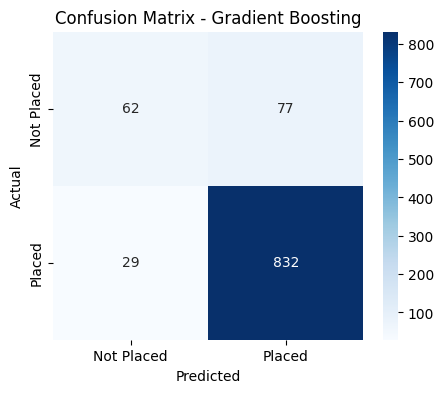

Evaluasi Akhir - Regresi


,Model,MAE,MSE,RMSE,R2 Score
0,CatBoostRegressor,1.117679,2.02561,1.423239,0.761204


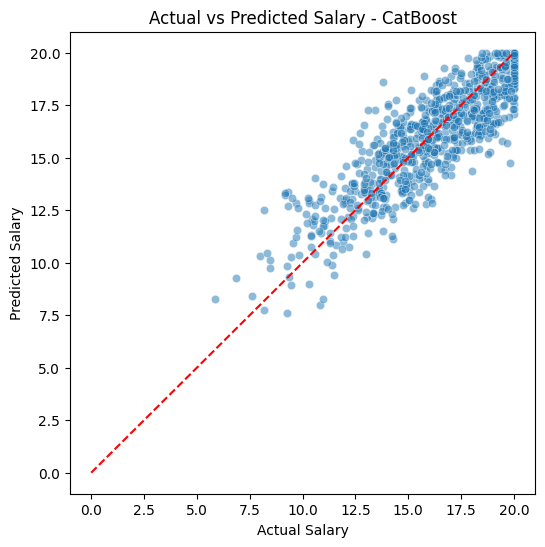

In [39]:
# Evaluasi akhir klasifikasi
clf_final = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', GradientBoostingClassifier(random_state=1))
])

clf_final.fit(Xc_train, yc_train_enc)

yc_pred = clf_final.predict(Xc_test)
yc_prob = clf_final.predict_proba(Xc_test)[:, 1]

clf_metrics = pd.DataFrame([{
    'Model': 'GradientBoostingClassifier',
    'Accuracy': accuracy_score(yc_test_enc, yc_pred),
    'F1 Score': f1_score(yc_test_enc, yc_pred),
    'ROC-AUC': roc_auc_score(yc_test_enc, yc_prob)
}])

print("Evaluasi Akhir - Klasifikasi")
display(clf_metrics)
print("\nClassification Report:")
print(classification_report(yc_test_enc, yc_pred, target_names=['Not Placed', 'Placed']))
print("\nConfusion Matrix:")
print(confusion_matrix(yc_test_enc, yc_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(yc_test_enc, yc_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluasi akhir regresi
reg_final = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', CatBoostRegressor(random_state=1, verbose=0))
])

reg_final.fit(Xr_train, yr_train)

yr_pred = reg_final.predict(Xr_test)
yr_pred = np.clip(yr_pred, None, 20)

reg_metrics = pd.DataFrame([{
    'Model': 'CatBoostRegressor',
    'MAE': mean_absolute_error(yr_test, yr_pred),
    'MSE': mean_squared_error(yr_test, yr_pred),
    'RMSE': np.sqrt(mean_squared_error(yr_test, yr_pred)),
    'R2 Score': r2_score(yr_test, yr_pred)
}])

print("Evaluasi Akhir - Regresi")
display(reg_metrics)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=yr_test, y=yr_pred, alpha=0.5)
plt.plot([0, 20], [0, 20], 'r--')
plt.title('Actual vs Predicted Salary - CatBoost')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.show()

Model Gradient Boosting mengalami kesulitan dalam memprediksi kelas Not Placed terutama karena ketidakseimbangan data (data imbalance), di mana jumlah data Placed jauh lebih dominan dibandingkan Not Placed. Dalam kondisi seperti ini, proses pembelajaran model cenderung lebih “terbias” terhadap pola dari kelas mayoritas karena kontribusinya terhadap error total jauh lebih besar. Akibatnya, model menjadi kurang sensitif terhadap karakteristik kelas minoritas. Hal ini terlihat dari nilai recall Not Placed yang rendah (0.45), yang berarti banyak data Not Placed justru salah diprediksi sebagai Placed.

Walaupun demikian, untuk kesiapan deployment, kedua model sebenarnya sudah cukup layak digunakan dengan konteks penggunaan yang berbeda. **Model klasifikasi (Gradient Boosting) siap digunakan jika tujuan utamanya adalah mengidentifikasi kandidat Placed secara akurat** karena performanya sangat baik pada kelas mayoritas. Namun, jika keputusan bisnis sangat bergantung pada deteksi Not Placed (misalnya untuk intervensi atau pencegahan), maka model ini masih perlu perbaikan lebih lanjut sebelum deployment, seperti penanganan imbalance lanjutan atau penyesuaian threshold. Sementara itu, **model regresi (CatBoostRegressor) dapat dikatakan lebih siap lagi untuk dideploy karena mampu memprediksi nilai gaji dengan cukup stabil** (R² ~0.76 dan error relatif rendah), serta pola prediksinya sudah mengikuti distribusi aktual dengan baik sehingga dapat diandalkan untuk estimasi nilai kontinu dalam skenario nyata.